# 📊 E-Commerce Sales Analysis — Tasks

## Phase 1: Data Understanding

### Task 1: Load Dataset

Load the CSV file into a pandas DataFrame.

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('superstore.csv',encoding='latin1')

Display the first 5 rows of the dataset.

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Task 2: Dataset Shape

Find how many rows and columns are in the dataset.

In [5]:
print(f'There are {df.shape[0]} rows and {df.shape[1]} columns')

There are 9994 rows and 21 columns


### Task 3: Column Names

List all column names.

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

### Task 4: Data Information

Check data types of all columns.

In [7]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Identify numeric and categorical columns.

<hr> numeric columns are <i>Row Id, Postal Code, Sales, Quantity, Discount, Profit</i><hr>
categorical columns are <i>Segment,Ship Mode, Country, City, State, Postal Code, Region, Category, Sub-Category, Quantity</i><hr>
date and time columns are <i>Order Date, Ship Date</i><hr>

## Phase 2: Data Cleaning

### Task 5: Missing Values

Check if there are any missing values in the dataset.

In [8]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Count missing values for each column.

<hr><i> There are no null values each columns </i><hr>

### Task 6: Duplicate Rows

Check if there are any duplicate rows in the dataset.

In [9]:
df.duplicated().sum()

np.int64(0)

Count total duplicate rows.

<hr><i> There are no duplicated values each columns </i><hr>

### Task 7: Date Conversion

Convert the “Order Date” and "Ship Date" columns to datetime format.

In [10]:
def datetime_correction(dataframe,column):
    dataframe[column] = pd.to_datetime(dataframe[column])
    return dataframe[column].dtypes

In [11]:
datetime_correction(df,'Order Date')
datetime_correction(df,'Ship Date')

dtype('<M8[us]')

Check the updated data type.

In [12]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## Phase 3: Basic Analysis

### Task 8: Total Sales

Calculate the total sales of the company.

In [13]:
total_sales = df['Sales'].sum()
total_sales

np.float64(2297200.8603)

### Task 9: Total Profit

Calculate the total profit of the company.

In [14]:
total_profits = df['Profit'].sum()
total_profits

np.float64(286397.0217)

### Task 10: Average Sales per Order

Find the average sales value per order.

In [15]:
total_orders = df.shape[0]
average_sales_per_order = total_sales / total_orders
print(f'The ecommerce website approximately sold ${average_sales_per_order.round(2)} dollers per order.')

The ecommerce website approximately sold $229.86 dollers per order.


### Task 11: Top Products by Sales

Find the top 10 products with highest sales.

In [16]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

### Task 12: Top Products by Profit

Find the top 10 products with highest profit.

In [17]:
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

### Task 13: Loss Making Products

Find products that have negative profit.

In [18]:
df[df['Profit']<0].groupby('Product Name')['Profit'].sum().sort_values(ascending=True).head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
GBC DocuBind P400 Electric Binding System                                     -6859.3896
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
GBC DocuBind TL300 Electric Binding System                                    -4162.0336
Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -3107.5272
Ibico EPK-21 Electric Binding System                                          -2929.4845
Bush Advantage Collection Racetrack Conference Table                          -2545.2600
Name: Profit, dtype: float64

## Phase 4: Customer Analysis

### Task 14: Top Customers by Sales

Find the top 10 customers who generated highest sales.

In [19]:
customer_df = df[['Customer Name','Sales','Profit']]
customer_df

,Customer Name,Sales,Profit
0,Claire Gute,261.9600,41.9136
1,Claire Gute,731.9400,219.5820
2,Darrin Van Huff,14.6200,6.8714
3,Sean O'Donnell,957.5775,-383.0310
4,Sean O'Donnell,22.3680,2.5164
...,...,...,...
9989,Tom Boeckenhauer,25.2480,4.1028
9990,Dave Brooks,91.9600,15.6332
9991,Dave Brooks,258.5760,19.3932
9992,Dave Brooks,29.6000,13.3200


In [20]:
top_customers = customer_df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

### Task 15: Top Customers by Profit

Find the top 10 customers who generated highest profit.

In [21]:
customer_df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

## Phase 5: Regional Analysis

### Task 16: Sales by Region

Calculate total sales for each region.

In [22]:
region_df = df[['City','Region','Sales','Profit']]
region_df

,City,Region,Sales,Profit
0,Henderson,South,261.9600,41.9136
1,Henderson,South,731.9400,219.5820
2,Los Angeles,West,14.6200,6.8714
3,Fort Lauderdale,South,957.5775,-383.0310
4,Fort Lauderdale,South,22.3680,2.5164
...,...,...,...,...
9989,Miami,South,25.2480,4.1028
9990,Costa Mesa,West,91.9600,15.6332
9991,Costa Mesa,West,258.5760,19.3932
9992,Costa Mesa,West,29.6000,13.3200


In [23]:
region_df['Region'].unique()

<ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

In [24]:
sales_by_region = region_df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sales_by_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

### Task 17: Profit by Region

Calculate total profit for each region.

In [25]:
profit_by_region = region_df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
profit_by_region

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

### Task 18: Top States by Sales

Find top 10 states with highest sales.

In [26]:
region_df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64

## Phase 6: Category Analysis

### Task 19: Sales by Category

Compare sales between Furniture, Technology, and Office Supplies.

In [27]:
category_df =df[['Category','Sub-Category','Sales','Profit']]
category_df

,Category,Sub-Category,Sales,Profit
0,Furniture,Bookcases,261.9600,41.9136
1,Furniture,Chairs,731.9400,219.5820
2,Office Supplies,Labels,14.6200,6.8714
3,Furniture,Tables,957.5775,-383.0310
4,Office Supplies,Storage,22.3680,2.5164
...,...,...,...,...
9989,Furniture,Furnishings,25.2480,4.1028
9990,Furniture,Furnishings,91.9600,15.6332
9991,Technology,Phones,258.5760,19.3932
9992,Office Supplies,Paper,29.6000,13.3200


In [28]:
category_df['Category'].unique()

<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

In [29]:
sales_by_categories = category_df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sales_by_categories

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

### Task 20: Profit by Category

Find which category is most profitable.

In [30]:
profit_by_categories = category_df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
profit_by_categories

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

### Task 21: Sub-Category Analysis

Find the most profitable sub-category.

In [31]:
category_df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Name: Profit, dtype: float64

## Phase 7: Time Analysis

### Task 22: Monthly Sales Trend

Find sales trend based on months.

In [32]:
time_analysis_df = df[['Order Date','Sales','Profit']]
time_analysis_df['Months'] = time_analysis_df['Order Date'].dt.month
time_analysis_df['Years'] = time_analysis_df['Order Date'].dt.year

In [33]:
#time_analysis_df.sort_values(by=['Months','Years'],ascending=True)

In [34]:
time_analysis_df

,Order Date,Sales,Profit,Months,Years
0,2016-11-08,261.9600,41.9136,11,2016
1,2016-11-08,731.9400,219.5820,11,2016
2,2016-06-12,14.6200,6.8714,6,2016
3,2015-10-11,957.5775,-383.0310,10,2015
4,2015-10-11,22.3680,2.5164,10,2015
...,...,...,...,...,...
9989,2014-01-21,25.2480,4.1028,1,2014
9990,2017-02-26,91.9600,15.6332,2,2017
9991,2017-02-26,258.5760,19.3932,2,2017
9992,2017-02-26,29.6000,13.3200,2,2017


In [35]:
monthly_sales_trend = time_analysis_df.groupby('Months')['Sales'].sum().sort_values(ascending=False)
monthly_sales_trend

Months
11    352461.0710
12    325293.5035
9     307649.9457
3     205005.4888
10    200322.9847
8     159044.0630
5     155028.8117
6     152718.6793
7     147238.0970
4     137762.1286
1      94924.8356
2      59751.2514
Name: Sales, dtype: float64

### Task 23: Monthly Profit Trend

Find profit trend based on months.

In [36]:
monthly_profit_trend = time_analysis_df.groupby('Months')['Profit'].sum().sort_values(ascending=False)
monthly_profit_trend

Months
12    43369.1919
9     36857.4753
11    35468.4265
10    31784.0413
3     28594.6872
5     22411.3078
8     21776.9384
6     21285.7954
7     13832.6648
4     11587.4363
2     10294.6107
1      9134.4461
Name: Profit, dtype: float64

### Task 24: Yearly Growth

Check if sales are increasing year by year.

In [37]:
time_analysis_df.groupby('Years')['Sales'].sum().sort_values(ascending=False)

Years
2017    733215.2552
2016    609205.5980
2014    484247.4981
2015    470532.5090
Name: Sales, dtype: float64

## Phase 8: Insights

### Task 25: Business Insights

### Write answers for:

In [38]:
df['Discount'].nunique()

12

In [39]:
df.groupby('Discount')['Profit'].sum().sort_values(ascending=False)

Discount
0.00    320987.6032
0.20     90337.3060
0.10      9029.1770
0.15      1418.9915
0.32     -2391.1377
0.45     -2493.1111
0.60     -5944.6552
0.30    -10369.2774
0.50    -20506.4281
0.40    -23057.0504
0.80    -30539.0392
0.70    -40075.3569
Name: Profit, dtype: float64

1. Most profitable category: Technology is the most profitable category in the business.
2. Weak regions fior sales: The South region has the lowest sales compared to other regions. 
3. Loss-making products: Some products generate negative profit. One of the biggest loss-making products is the Cubify CubeX 3D Printer Double Head Print.
4. Effect of discount on profit: Higher discounts reduce profit. Discounts above 30% often lead to losses.Discounts below 15% usually maintain positive profit. 
5. 5 business recommendations: Copiers, Phones, Accessories, Paper, Binders are the most recomment items.

## Phase 9: Visualization

### Task 26: Charts

### Create at least 8 visualizations:

1. Monthly sales trend (line chart)
2. Monthly profit trend (line chart)
3. Sales by region (bar chart)
4. Profit by region (bar chart)
5. Sales by category (bar chart)
6. Profit by category (bar chart)
7. Top 10 products (bar chart)
8. Top 10 customers (bar chart)

#### 1. Monthly sales trend (line chart)

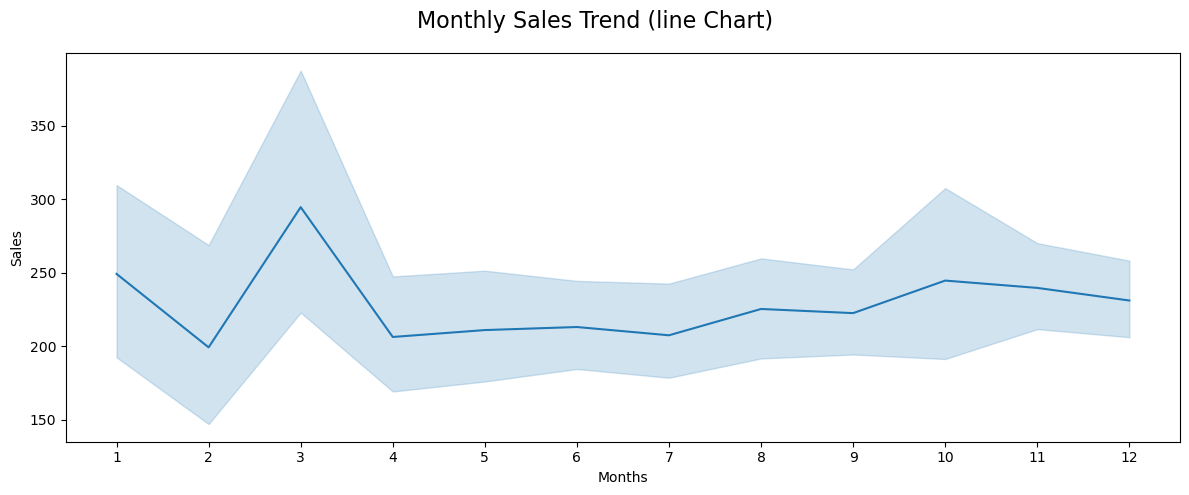

In [40]:
plt.figure(figsize=(12,5))
sns.lineplot(y='Sales',x='Months',data=time_analysis_df)
plt.suptitle('Monthly Sales Trend (line Chart)',fontsize=16)
plt.xlabel('Months')
plt.ylabel('Sales')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

Conclusion: Sales were highest in March and second highest in October. February had the lowest sales during the analyzed period.

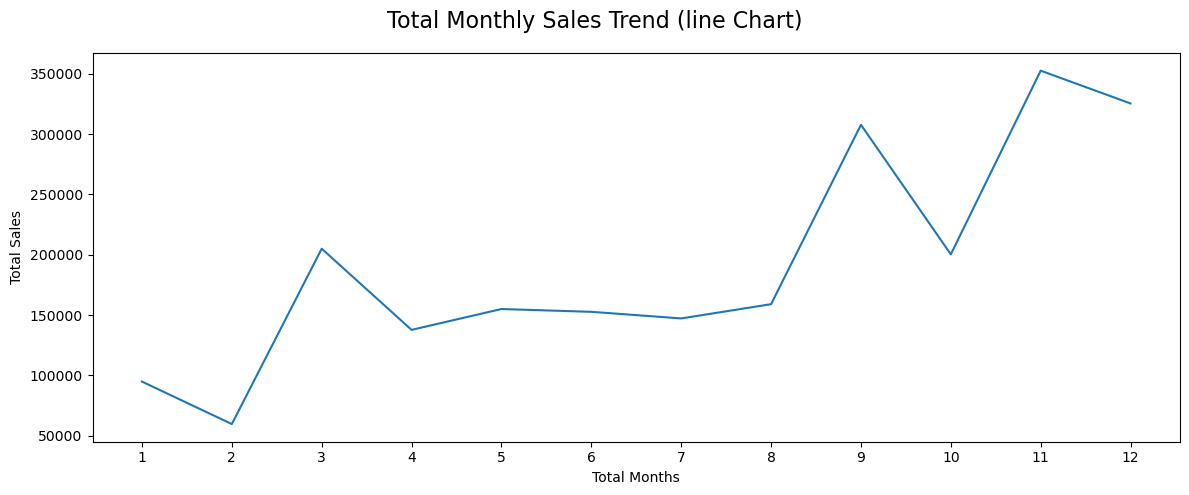

In [41]:
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_sales_trend.index,y=monthly_sales_trend.values)
plt.suptitle('Total Monthly Sales Trend (line Chart)',fontsize=16)
plt.xlabel('Total Months')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

Conclusion: The sales trend was generally positive throughout the year, with some ups and downs. The highest sales were in Month November (11), showing overall business growth.

#### 2. Monthly Profit Trend line Chart

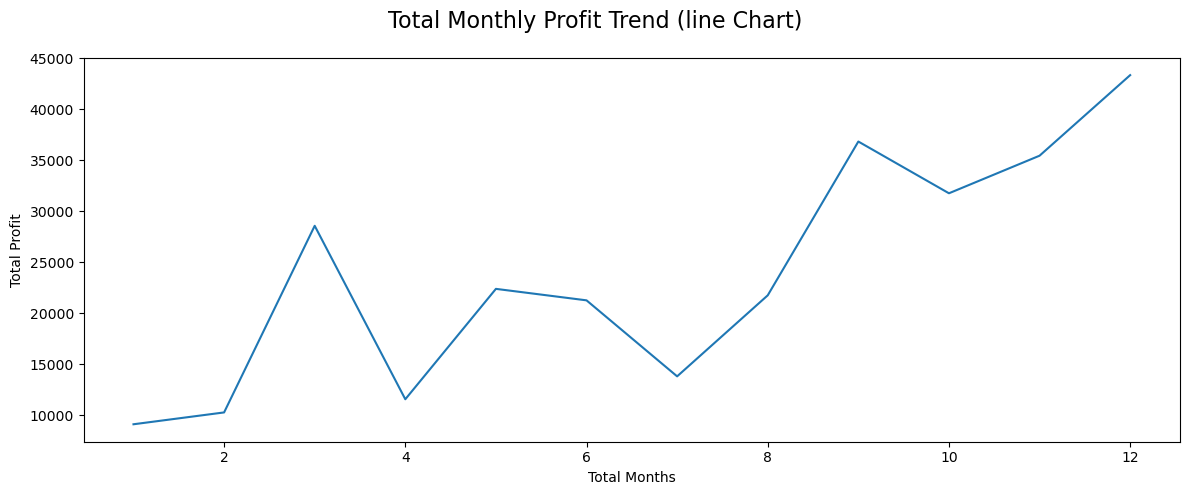

In [42]:
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_profit_trend.index,y=monthly_profit_trend.values)
plt.suptitle('Total Monthly Profit Trend (line Chart)',fontsize=16)
plt.xlabel('Total Months')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

#### 3. Sales by region (bar chart)

C:\Users\fothe\AppData\Local\Temp\ipykernel_12752\756463109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_region.index,y=sales_by_region.values,palette='rainbow')


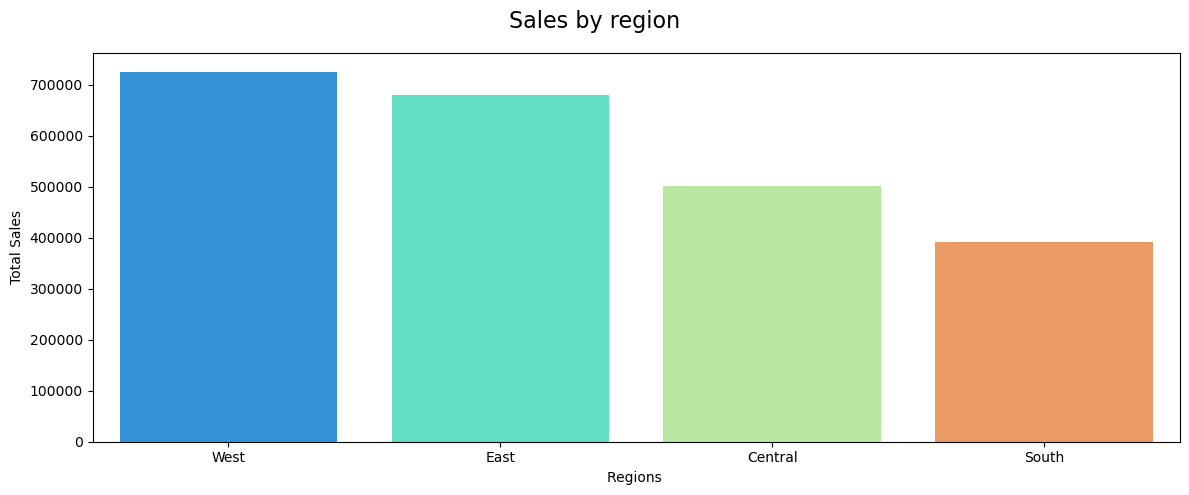

In [43]:
plt.figure(figsize=(12,5))
sns.barplot(x=sales_by_region.index,y=sales_by_region.values,palette='rainbow')
plt.suptitle('Sales by region',fontsize=16)
plt.xlabel('Regions ')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

#### 4. Profit by region (bar chart)

C:\Users\fothe\AppData\Local\Temp\ipykernel_12752\3350500162.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_region.index,y=profit_by_region.values,palette='rainbow')


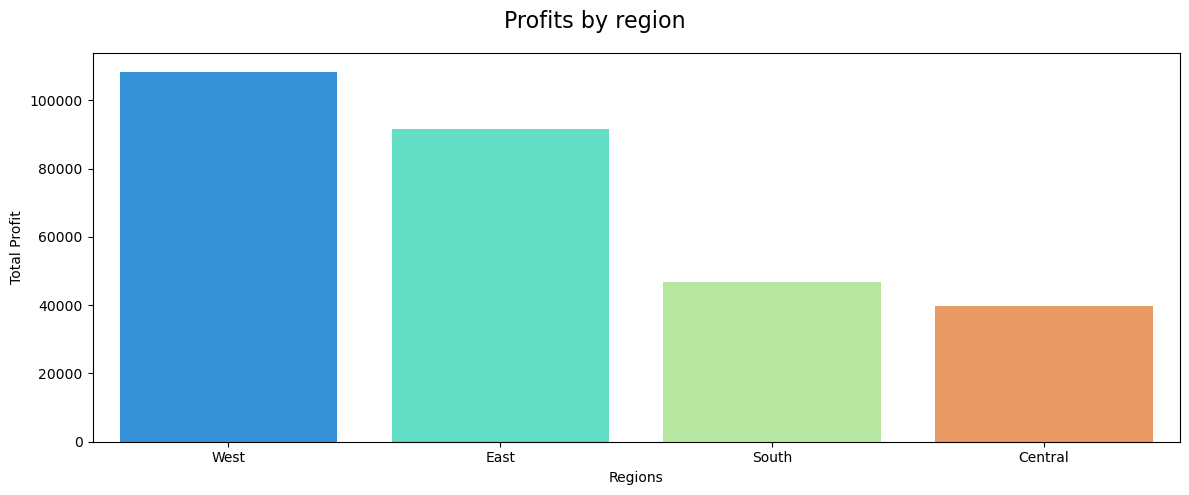

In [44]:
plt.figure(figsize=(12,5))
sns.barplot(x=profit_by_region.index,y=profit_by_region.values,palette='rainbow')
plt.suptitle('Profits by region',fontsize=16)
plt.xlabel('Regions')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

#### 5. Sales by category (bar chart)

C:\Users\fothe\AppData\Local\Temp\ipykernel_12752\60236135.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_categories.index,y=sales_by_categories.values,palette='rainbow')


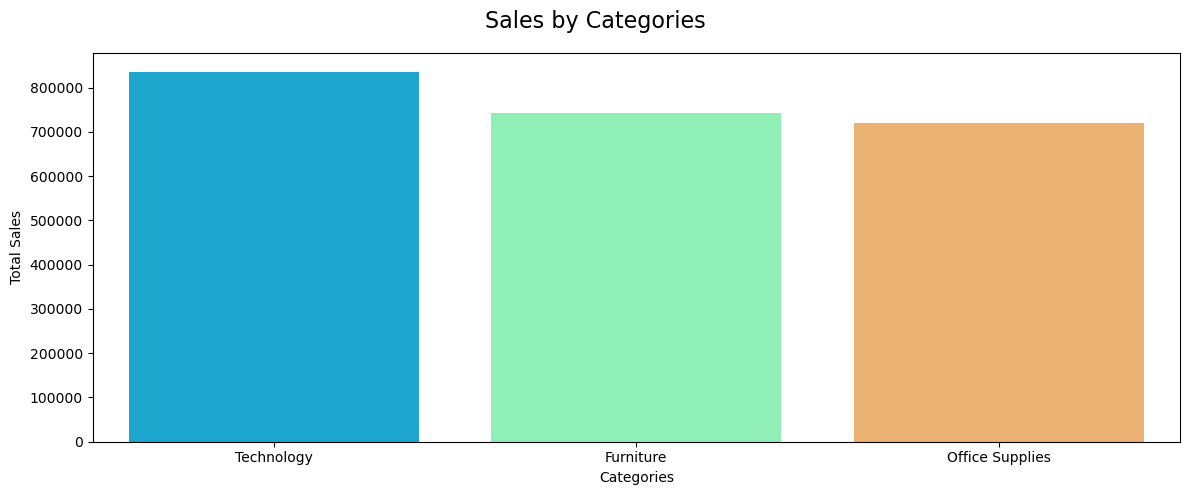

In [45]:
plt.figure(figsize=(12,5))
sns.barplot(x=sales_by_categories.index,y=sales_by_categories.values,palette='rainbow')
plt.suptitle('Sales by Categories',fontsize=16)
plt.xlabel('Categories')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

#### 6. Profit by category (bar chart)

C:\Users\fothe\AppData\Local\Temp\ipykernel_12752\3384266088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_categories.index,y=profit_by_categories.values,palette='rainbow')


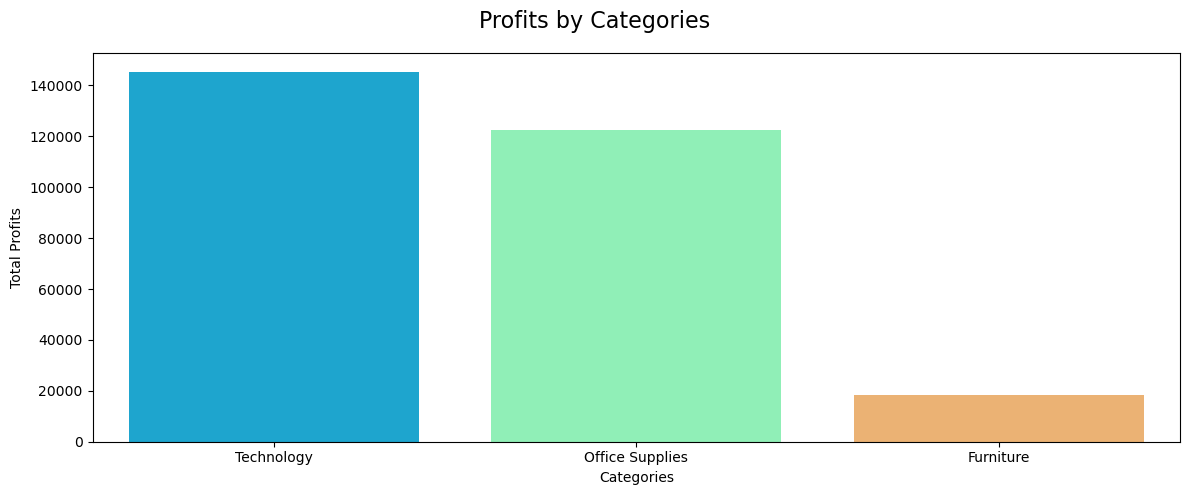

In [46]:
plt.figure(figsize=(12,5))
sns.barplot(x=profit_by_categories.index,y=profit_by_categories.values,palette='rainbow')
plt.suptitle('Profits by Categories',fontsize=16)
plt.xlabel('Categories')
plt.ylabel('Total Profits')
plt.tight_layout()
plt.show()

#### 7. Top 10 products (bar chart)

C:\Users\fothe\AppData\Local\Temp\ipykernel_12752\4181967750.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values,y=top_products.index,palette='rainbow')


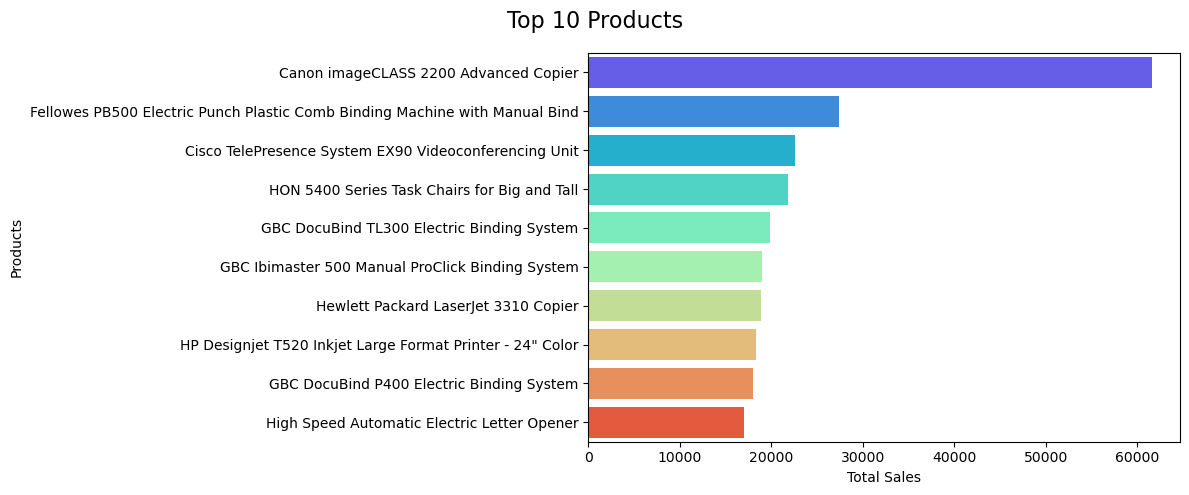

In [48]:
plt.figure(figsize=(12,5))
sns.barplot(x=top_products.values,y=top_products.index,palette='rainbow')
plt.suptitle('Top 10 Products',fontsize=16)
plt.xlabel('Total Sales')
plt.ylabel('Products')
plt.tight_layout()
plt.show()

#### 8. Top 10 customers (bar chart)

C:\Users\fothe\AppData\Local\Temp\ipykernel_12752\1696483931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values,y=top_customers.index,palette='rainbow')


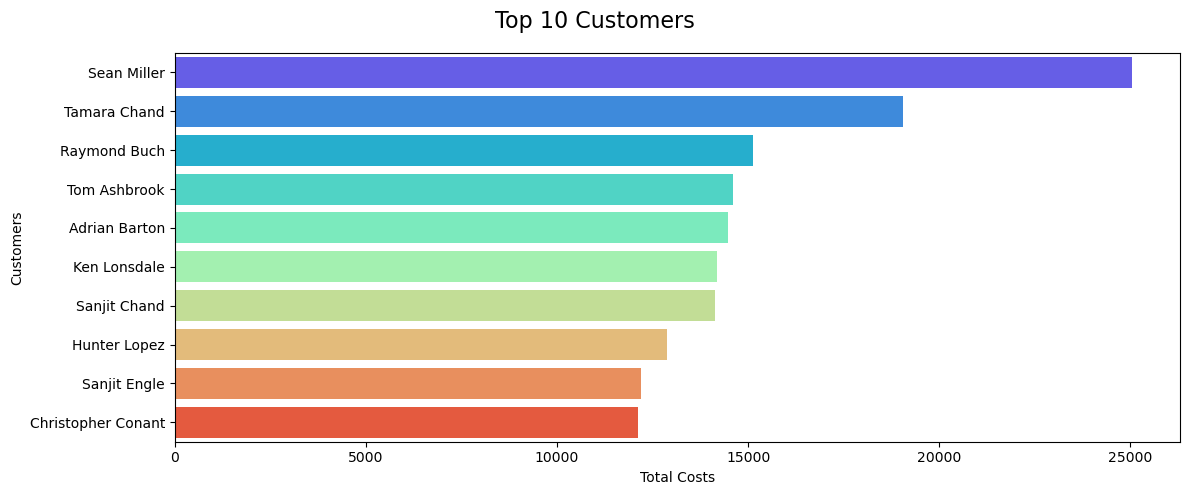

In [49]:
plt.figure(figsize=(12,5))
sns.barplot(x=top_customers.values,y=top_customers.index,palette='rainbow')
plt.suptitle('Top 10 Customers',fontsize=16)
plt.xlabel('Total Costs')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

# The End